In [1]:
import scanpy as sc 
import matplotlib.pyplot as plt
sc.settings.figdir="..results/figures"

In [2]:
adata=sc.read_h5ad('../data/processed/nsclc_clustered.h5ad')

In [3]:
#find markers 
sc.tl.rank_genes_groups(adata,groupby='leiden',method='wilcoxon')

/opt/miniconda3/envs/singlecell/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/miniconda3/envs/singlecell/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/opt/miniconda3/envs/singlecell/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarni

In [5]:
#results stored in 
adata.uns['rank_genes_groups']

{'params': {'groupby': 'leiden',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': True,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('RPL34', 'CD79A', 'CCL5', 'NKG7', 'FTL', 'MARCO', 'LST1', 'S100A6', 'IL32', 'IGKC', 'CYB5A', 'MGP', 'ZFAS1', 'AGR2', 'MZB1', 'TPSAB1', 'HSPB1', 'RAMP2', 'STMN1', 'CHCHD2', 'TFF3', 'SFTPC', 'HP', 'HIST1H1C', 'SFTPC', 'JCHAIN', 'CRYAB', 'CAPS', 'H2AFZ', 'HBA1'),
            ('RPS27', 'CD37', 'IL32', 'CST7', 'GPX1', 'MCEMP1', 'LYZ', 'KRT18', 'TRAC', 'IGLC2', 'RNASE1', 'DCN', 'S100A14', 'HMGB3', 'SSR4', 'TPSB2', 'CD9', 'GNG11', 'TUBB', 'SEC61G', 'SCGB3A1', 'IGKC', 'SCGB3A1', 'STMN1', 'NAPSA', 'SEC61B', 'GPM6B', 'TPPP3', 'HMGN2', 'HBA2'),
            ('RPS29', 'MS4A1', 'CD3D', 'GZMB', 'CTSB', 'FBP1', 'CST3', 'WFDC2', 'HLA-A', 'BTG1', 'SFTA2', 'IGFBP7', 'CLDN4', 'DEFB1', 'DERL3', 'CPA3', 'MGST1', 'CLDN5', 'HMGB2', 'CST6', 'BPIFB2', 'RPS26', 'MUC5B', 'SOX4', 'SFTPA1', 'PLAC8', 'MBP', 'RSPH1', 'KIAA0101', 'HBB'),
     

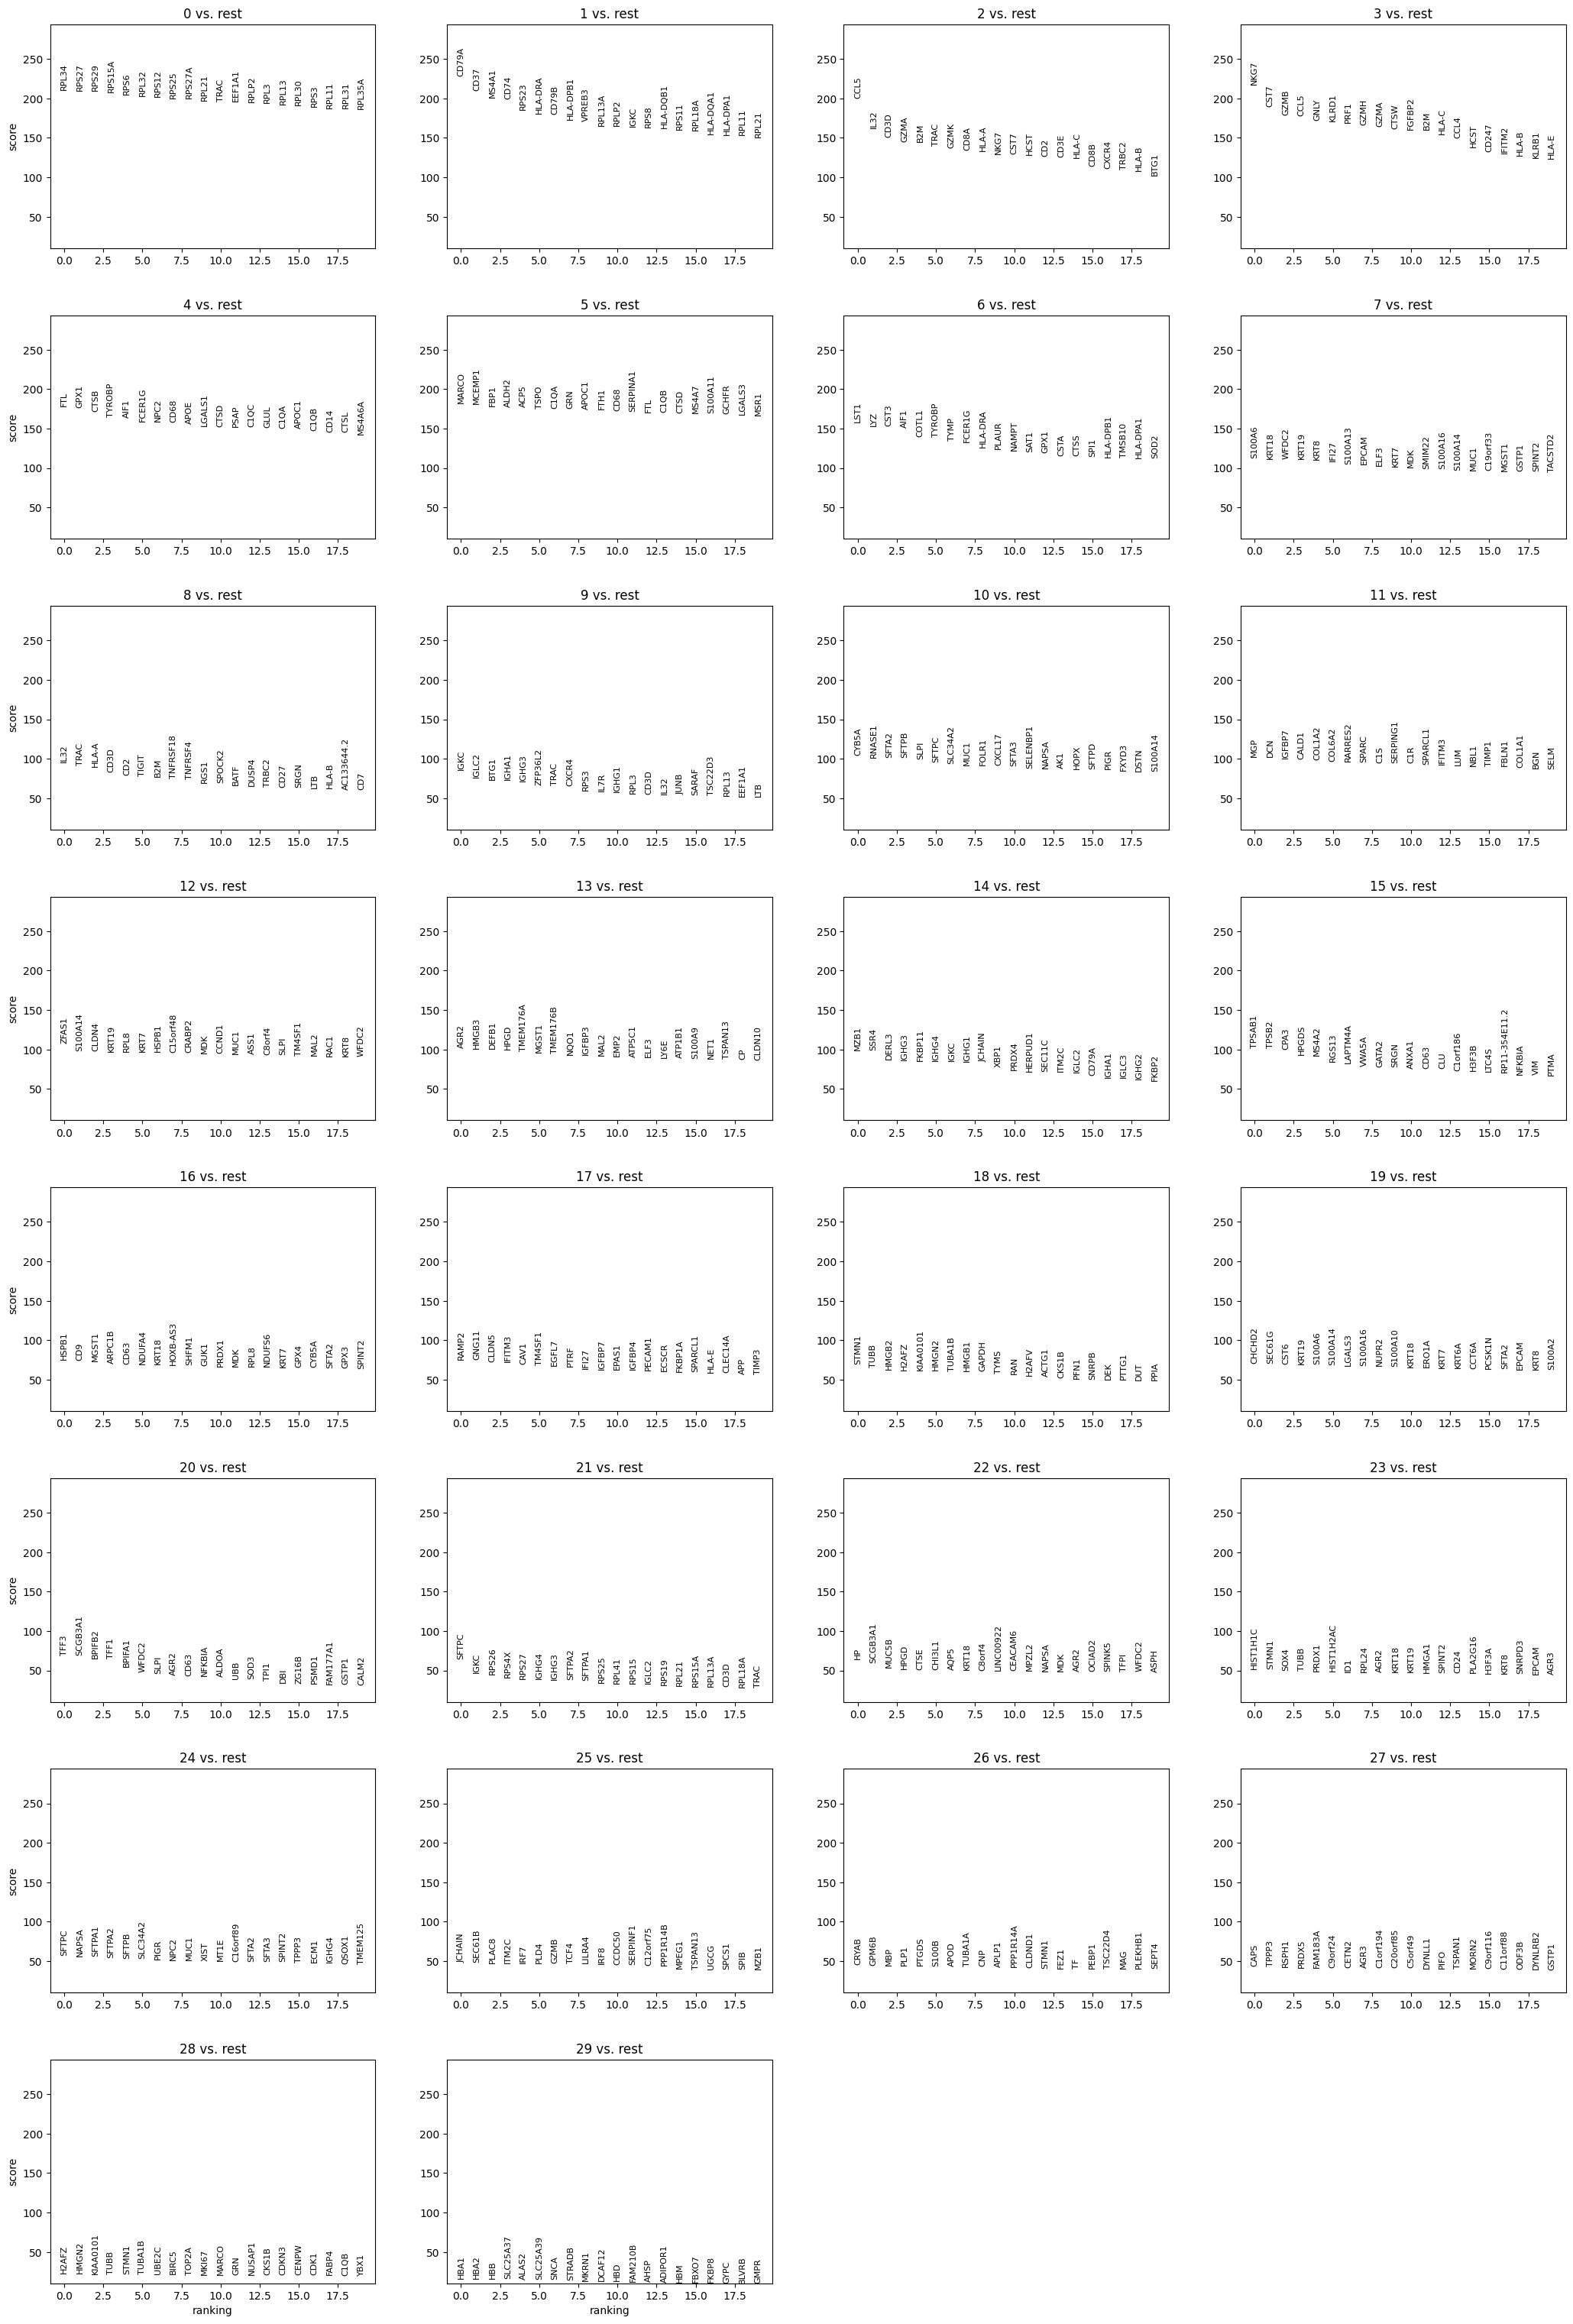

In [6]:
#visuallize top marker genes 

sc.pl.rank_genes_groups(adata,n_genes=20,save='_rank_genes.png')

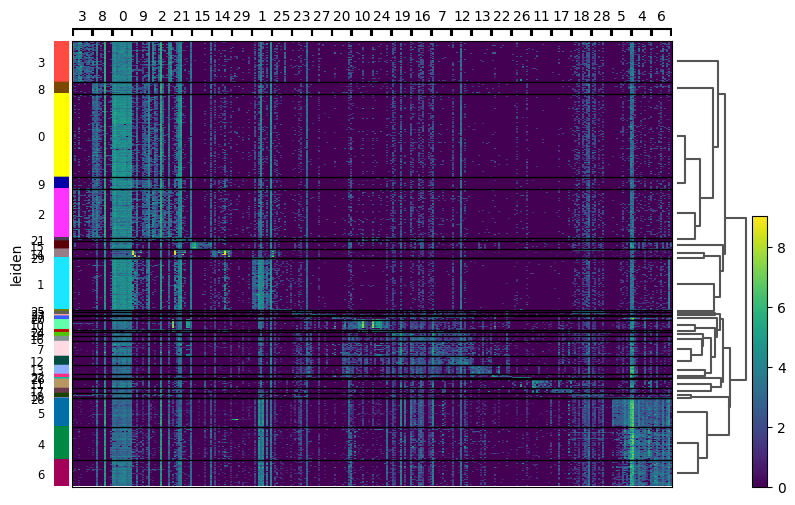

In [7]:
#heatmap for marker genes 

sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    groupby='leiden',
    save='_marker_heatmap.png'
)

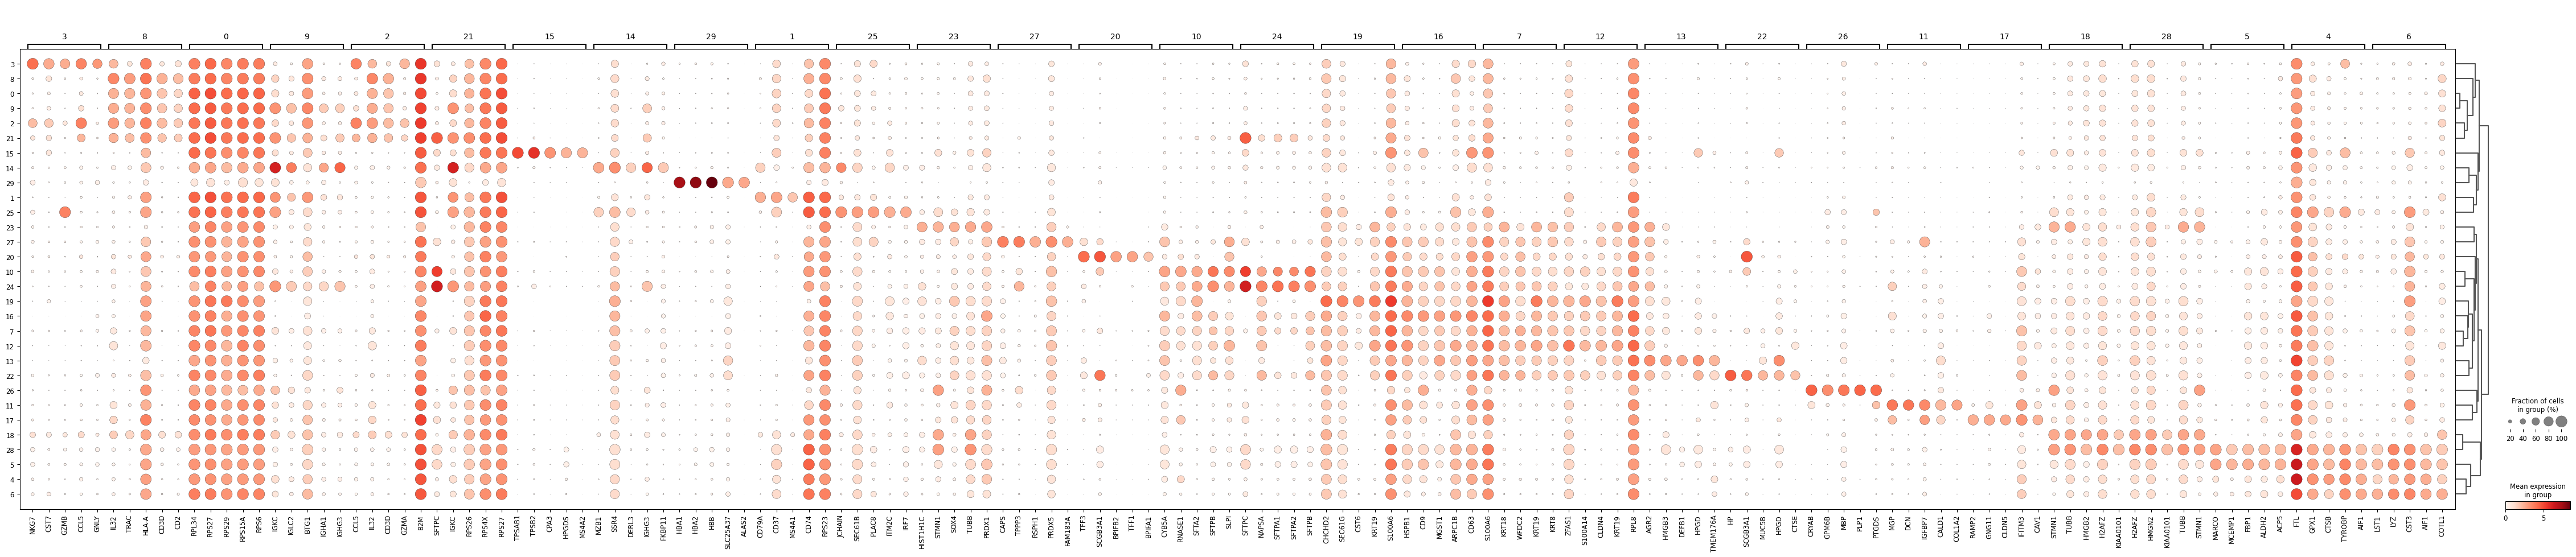

In [8]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    save='_marker_dotplot.png'
)

In [10]:
#export marker genes
import pandas as pd

markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])

markers.to_csv("../results/tables/marker_genes.csv",index=False)

In [11]:
df =pd.read_csv('../results/tables/marker_genes.csv')

In [12]:
df

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,RPL34,CD79A,CCL5,NKG7,FTL,MARCO,LST1,S100A6,IL32,IGKC,...,TFF3,SFTPC,HP,HIST1H1C,SFTPC,JCHAIN,CRYAB,CAPS,H2AFZ,HBA1
1,RPS27,CD37,IL32,CST7,GPX1,MCEMP1,LYZ,KRT18,TRAC,IGLC2,...,SCGB3A1,IGKC,SCGB3A1,STMN1,NAPSA,SEC61B,GPM6B,TPPP3,HMGN2,HBA2
2,RPS29,MS4A1,CD3D,GZMB,CTSB,FBP1,CST3,WFDC2,HLA-A,BTG1,...,BPIFB2,RPS26,MUC5B,SOX4,SFTPA1,PLAC8,MBP,RSPH1,KIAA0101,HBB
3,RPS15A,CD74,GZMA,CCL5,TYROBP,ALDH2,AIF1,KRT19,CD3D,IGHA1,...,TFF1,RPS4X,HPGD,TUBB,SFTPA2,ITM2C,PLP1,PRDX5,TUBB,SLC25A37
4,RPS6,RPS23,B2M,GNLY,AIF1,ACP5,COTL1,KRT8,CD2,IGHG3,...,BPIFA1,RPS27,CTSE,PRDX1,SFTPB,IRF7,PTGDS,FAM183A,STMN1,ALAS2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27273,FTL,S100A10,FTL,COTL1,RPL13A,RPS27A,RPL23A,BTG1,NPC2,HLA-DRB1,...,RPS28,MT-ATP6,RPS29,TPT1,RPS23,ANXA1,RPLP2,RPS18,RPL35A,RPL41
27274,CD63,S100A4,FTH1,LTB,RPS3,MALAT1,RPL3,HLA-E,CST3,HLA-DPA1,...,RPS29,MT-CO1,RPL26,HLA-C,B2M,MT-CO3,RPS18,TMSB10,RPS27,RPL28
27275,HLA-DRB1,S100A11,CST3,RPL8,RPS27,RPL23A,RPS3,LAPTM5,FTL,GSTP1,...,RPL28,MT-ND1,B2M,HLA-A,RPL3,BTG1,RPL10,RPS12,MALAT1,EEF1A1
27276,HLA-DRA,ANXA1,GPX1,NPC2,RPL3,RPL13,IL32,CD52,GSTP1,HLA-DRA,...,RPS27,RPS4Y1,HLA-C,B2M,RPS6,MT-CYB,RPL27A,RPL10,RPL10,RPL10


In [13]:
adata.write('../data/processed/nsclc_markers.h5ad')